In [1]:
import pandas as pd
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import folium
from IPython.display import display
import spaghetti
import esda

/opt/anaconda3/envs/nda/lib/python3.11/site-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


## Task A

Clean and standardise the dataset of road traffic accidents in Leeds from 2012 to 2016. Rename key columns to a uniform format, remove irrelevant columns, retain only the variables required for this task, and convert the easting and northing fields to numerical values. Once the data cleaning is complete, merge all annual datasets into a single table. 

In [2]:
def clean_data_file(file_path, year):
    df=pd.read_csv(file_path, encoding='latin1')
    df.columns=df.columns.str.strip()

    file_column={
        'Reference Number':'reference_number',
        'Easting':'easting',
        'Northing':'northing',
        'Grid Ref: Easting':'easting',
        'Grid Ref: Northing':'northing',
        'Accident Date':'accident_date'
    }
    df=df.rename(columns=file_column)

    drop_columns=[]
    for col in df.columns:
        if 'Unnamed' in col or col=='Expr1':
            drop_columns.append(col)
    
    if len(drop_columns)>0:
        df=df.drop(columns=drop_columns)
    
    df['year']=year

    keep_columns=['reference_number', 'easting', 'northing', 'accident_date', 'year']

    existing_columns=[]
    for col in keep_columns:
        if col in df.columns:
            existing_columns.append(col)
    
    df=df[existing_columns].copy()

    df['easting']=pd.to_numeric(df['easting'], errors='coerce')
    df['northing']=pd.to_numeric(df['northing'], errors='coerce')

    df=df.dropna(subset=['easting', 'northing'])

    if 'reference_number' in df.columns:
        df['reference_number']=df['reference_number'].astype(str).str.strip()
    
    return df

def clean_2012_2016_dataset():
    file_data={
        2012:'2012.csv',
        2013:'2013.csv',
        2014:'2014.csv',
        2015:'2015.csv',
        2016:'Copy of Leeds_RTC_2016.csv',
    }
    cleaned_df=[]

    for year in file_data:
        file_path=file_data[year]
        df_year=clean_data_file(file_path, year)
        cleaned_df.append(df_year)

        print('Year:', year)
        print('The cleaned rows:', len(df_year))
        print('Columns:', list(df_year.columns))
        print()
    
    all_rows=pd.concat(cleaned_df, ignore_index=True)
    return all_rows

def build_accident_dataset(row_df):
    accident_df=row_df.copy()
    accident_df=accident_df.drop_duplicates(subset=['reference_number', 'easting', 'northing']).copy()
    return accident_df

all_rows=clean_2012_2016_dataset()
print(all_rows.head())
print(all_rows.shape)
print(all_rows.isna().sum())

accident_df=build_accident_dataset(all_rows)
print(accident_df.head())
print(accident_df.shape)
print(all_rows['reference_number'].nunique())
print(len(all_rows))

Year: 2012
The cleaned rows: 2748
Columns: ['reference_number', 'easting', 'northing', 'accident_date', 'year']

Year: 2013
The cleaned rows: 2433
Columns: ['reference_number', 'easting', 'northing', 'accident_date', 'year']

Year: 2014
The cleaned rows: 2533
Columns: ['reference_number', 'easting', 'northing', 'accident_date', 'year']

Year: 2015
The cleaned rows: 2664
Columns: ['reference_number', 'easting', 'northing', 'accident_date', 'year']

Year: 2016
The cleaned rows: 2549
Columns: ['reference_number', 'easting', 'northing', 'accident_date', 'year']

  reference_number  easting  northing accident_date  year
0        120033394   430536    433129     22-Jan-12  2012
1        120034263   427301    434682     23-Jan-12  2012
2        120034970   422201    433910     23-Jan-12  2012
3        120035568   428891    431676     24-Jan-12  2012
4        120036061   442525    427843     24-Jan-12  2012
(12927, 5)
reference_number    0
easting             0
northing            0
accident_d

As the subsequent analysis is spatially based, it is necessary to compare the accidents with the candidate study areas and, ultimately, with the road network itself. Therefore, the cleaned accident table is converted into a GeoDataFrame. Each accident is represented as a point via its east and north coordinates. Representing accidents as geographical points allows us to examine which areas have the highest number of recorded accidents.


In [3]:
def build_accident_gdf(accident_df):
    gdf=gpd.GeoDataFrame(accident_df.copy(), geometry=gpd.points_from_xy(accident_df['easting'], accident_df['northing']), crs='EPSG:27700')
    return gdf

def get_leeds_centre_point():
    city_centre=ox.geocode_to_gdf('Leeds Civic Hall, Leeds, UK')
    city_centre=city_centre.to_crs('EPSG:27700')

    centre_point=city_centre.geometry.iloc[0].centroid
    centre_easting=centre_point.x
    centre_northing=centre_point.y

    print('The Point of Leeds Civic Hall Centre:')
    print('Easting:', centre_easting)
    print('Northing:', centre_northing)
    
    return centre_point

def candidate_window(centre_point, window_size=1000, step=250, search_area=500):
    half_size=window_size/2
    candidate_window=[]

    for x_shift in range(-search_area, search_area+1, step):
        for y_shift in range(-search_area, search_area+1, step):
            centre_x=centre_point.x+x_shift
            centre_y=centre_point.y+y_shift

            window_box=box(
                centre_x-half_size,
                centre_y-half_size,
                centre_x+half_size,
                centre_y+half_size
            )
            candidate_window.append({
                'x_shift':x_shift,
                'y_shift':y_shift,
                'centre_x':centre_x,
                'centre_y':centre_y,
                'geometry':window_box
            })
    window_gdf=gpd.GeoDataFrame(candidate_window, geometry='geometry', crs='EPSG:27700')
    return window_gdf

def count_accidents(accident_gdf, window_gdf):
    accident_counts=[]

    for idx in window_gdf.index:
        current_window=window_gdf.loc[idx, 'geometry']
        window_accidents=accident_gdf[accident_gdf.geometry.within(current_window)]
        accident_counts.append(len(window_accidents))
    
    window_gdf=window_gdf.copy()
    window_gdf['accident_count']=accident_counts
    return window_gdf

def select_best_area(window_gdf):
    best_row=window_gdf.sort_values(by='accident_count',ascending=False).iloc[0]
    print('Selected area:')
    print('x_shift:', best_row['x_shift'])
    print('y_shift:', best_row['y_shift'])
    print('centre_x:', best_row['centre_x'])
    print('centre_y:', best_row['centre_y'])
    print('accident_count:', best_row['accident_count'])
    print()
    print('Bounding box coordinates:')
    print('west:', best_row['geometry'].bounds[0])
    print('south:', best_row['geometry'].bounds[1])
    print('east:', best_row['geometry'].bounds[2])
    print('north:', best_row['geometry'].bounds[3])
    print()
    return best_row

def select_test_area(accident_df):
    accident_points=build_accident_gdf(accident_df)
    centre_point=get_leeds_centre_point()

    window_gdf=candidate_window(centre_point, window_size=1000, step=250, search_area=500)
    window_gdf=count_accidents(accident_points, window_gdf)
    best_area=select_best_area(window_gdf)
    return accident_points, window_gdf, best_area

Two coordinate reference systems are used in this task:

'EPSG:27700' is the British National Grid, which the Ordnance Survey (Ordnance Survey: https://docs.os.uk/osngd/getting-started/os-ngd-fundamentals/coordinate-reference-systems) has designated as the standard projected coordinate system for Great Britain. This system uses east and north coordinates measured in metres, making it suitable for defining 1 km × 1 km study areas and calculating distance- and area-based metrics.

EPSG:4326 is the World Geodetic System 1984 (WGS 84) geographic coordinate reference system (Ordnance Survey: https://docs.os.uk/osngd/getting-started/os-ngd-fundamentals/coordinate-reference-systems). It uses latitude and longitude in degrees to represent positions and is the standard coordinate reference system adopted by many network maps and OpenStreetMap-based tools.

In this task, incident data and the study window were processed using EPSG:27700, as this system supports precise measurements in metres. The selected bounding boxes are subsequently converted to EPSG:4326 to facilitate road network extraction using OSMnx and OpenStreetMap features. 

Used OSMnx to download the road network within the selected study area. The parameter `network_type=“drive”` retains only roads suitable for vehicular traffic.

In [4]:
def get_bounding_box(best_area):
    west=best_area['geometry'].bounds[0]
    south=best_area['geometry'].bounds[1]
    east=best_area['geometry'].bounds[2]
    north=best_area['geometry'].bounds[3]

    print('Selected Bounding Box:')
    print('west:', west)
    print('south:', south)
    print('east:', east)
    print('north:', north)
    print()
    return west, south, east, north

def convert_bounding_box_to_osmnx(west, south, east, north):
    bounding_box_poly=ox.utils_geo.bbox_to_poly((west, south, east, north))
    bounding_box_gdf=gpd.GeoDataFrame(geometry=[bounding_box_poly], crs='EPSG:27700')
    bounding_box_gdf=bounding_box_gdf.to_crs('EPSG:4326')
    west_lon, south_lat, east_lon, north_lat=bounding_box_gdf.geometry.iloc[0].bounds
    print('Convert bounding box to OSMnx:')
    print('west', west_lon)
    print('south', south_lat)
    print('east', east_lon)
    print('north', north_lat)
    print()
    return west_lon, south_lat, east_lon, north_lat

def build_road_network(best_area):
    west, south, east, north=get_bounding_box(best_area)
    west_lon, south_lat, east_lon, north_lat=convert_bounding_box_to_osmnx(west, south, east, north)

    graph_road=ox.graph_from_bbox(bbox=(west_lon, south_lat, east_lon, north_lat), network_type='drive')
    print('Road network loaded.')
    print('Number of nodes:', len(graph_road.nodes))
    print('Number of edges:', len(graph_road.edges))
    print()
    return graph_road

def plot_road_network(graph_road):
    ox.plot_graph(graph_road)

def projected_road_network(graph_road):
    graph_road_projected=ox.project_graph(graph_road)
    print('Projected road network.')
    print('CRS:', graph_road_projected.graph['crs'])
    print()

    return graph_road_projected


def build_task_a_road_network(best_area):
    graph_road=build_road_network(best_area)
    plot_road_network(graph_road)
    graph_road_projected=projected_road_network(graph_road)
    return graph_road, graph_road_projected

The Point of Leeds Civic Hall Centre:
Easting: 429831.38488280564
Northing: 434088.41618407954
Selected area:
x_shift: 500
y_shift: -500
centre_x: 430331.38488280564
centre_y: 433588.41618407954
accident_count: 413

Bounding box coordinates:
west: 429831.38488280564
south: 433088.41618407954
east: 430831.38488280564
north: 434088.41618407954

Selected Bounding Box:
west: 429831.38488280564
south: 433088.41618407954
east: 430831.38488280564
north: 434088.41618407954

Convert bounding box to OSMnx:
west -1.5486416467815867
south 53.79321601778216
east -1.5333622433511618
north 53.80226178354041

Road network loaded.
Number of nodes: 169
Number of edges: 286



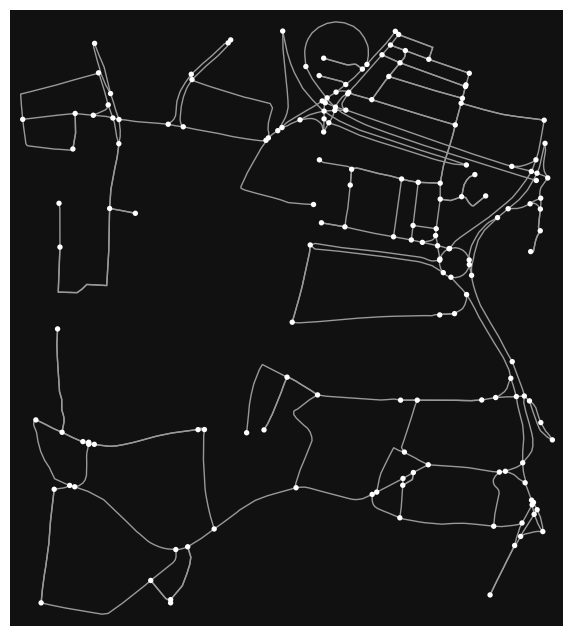

Projected road network.
CRS: EPSG:32630

Undirect road network:
Number of nodes: 169
Number of edges: 233

Connected components:
Number of connected components: 1

The largest connected components:
Number of nodes: 169
Number of edges: 233

Area size:
Area (square metres): 1000000.0
Area (square kilometres): 1.0

Spatial diameter:
Spatial diameter (m) 2925.227463997006

Average street length:
Average street length (m): 65.6375215799335

Node density:
Nodes per square kiolmetre: 169.0

Edge density:
Edges per square kiolmetre: 233.0

Intersection density:
Number of intersections: 125
Intersections per square kilometre: 125.0

Average circuitry:
Average circuitry: 1.0577552136997392

Planarity Check:
Is the road network planar? True

This road network is planar, a counterexample graph is not needed.

Summary table:
                                      Metric        Value
0             Number of connected components            1
1                                  Area (m2)    1000000.0
2

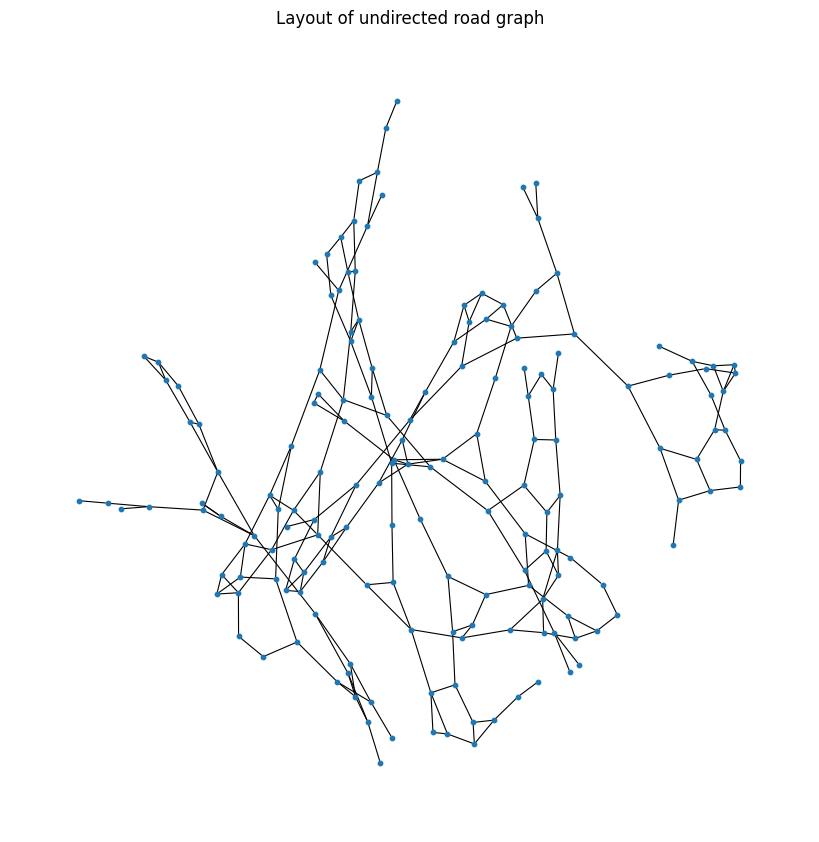

In [5]:
def build_undirect_graph(graph_road_projected):
    graph_road_undirected=graph_road_projected.to_undirected()
    print('Undirect road network:')
    print('Number of nodes:', graph_road_undirected.number_of_nodes())
    print('Number of edges:', graph_road_undirected.number_of_edges())
    print()
    return graph_road_undirected

def check_connected_components(graph_road_undirected):
    num_of_components=nx.number_connected_components(graph_road_undirected)
    print('Connected components:')
    print('Number of connected components:', num_of_components)
    print()
    return num_of_components

def build_largest_component(graph_road_undirected):
    largest=max(nx.connected_components(graph_road_undirected), key=len)
    component=graph_road_undirected.subgraph(largest).copy()
    print('The largest connected components:')
    print('Number of nodes:', component.number_of_nodes())
    print('Number of edges:', component.number_of_edges())
    print()

    return component

def get_area_size(best_area):
    area_m_square=best_area['geometry'].area
    area_km_square=area_m_square/1000000
    print('Area size:')
    print('Area (square metres):', area_m_square)
    print('Area (square kilometres):', area_km_square)
    print()
    return area_m_square, area_km_square

def spatial_diameter(component):
    all_path_lengths=dict(nx.all_pairs_dijkstra_path_length(component, weight='length'))

    spatial_diameter=0
    for node in all_path_lengths:
        longest_path=max(all_path_lengths[node].values())
        if longest_path>spatial_diameter:
            spatial_diameter=longest_path
    print('Spatial diameter:')
    print('Spatial diameter (m)', spatial_diameter)
    print()
    return spatial_diameter

def average_street_length(component):
    street_length=[]
    for u, v, data in component.edges(data=True):
        if 'length' in data:
            street_length.append(data['length'])
    average_street_length=sum(street_length)/len(street_length)

    print('Average street length:')
    print('Average street length (m):', average_street_length)
    print()

    return average_street_length

def get_node_density(component, area_km_square):
    num_nodes=component.number_of_nodes()
    node_density=num_nodes/area_km_square
    print('Node density:')
    print('Nodes per square kiolmetre:', node_density)
    print()
    return node_density

def get_edge_density(component, area_km_square):
    num_edges=component.number_of_edges()
    edge_density=num_edges/area_km_square
    print('Edge density:')
    print('Edges per square kiolmetre:', edge_density)
    print()
    return edge_density

def intersection_density(component, area_km_square):
    intersection_nodes=[]
    for node in component.nodes():
        if component.degree(node)>=3:
            intersection_nodes.append(node)
    
    number_of_intersections=len(intersection_nodes)
    intersection_density=number_of_intersections/area_km_square

    print('Intersection density:')
    print('Number of intersections:', number_of_intersections)
    print('Intersections per square kilometre:', intersection_density)
    print()
    return number_of_intersections, intersection_density

def average_circuitry(component):
    coords={n:np.array((component.nodes[n]['x'], component.nodes[n]['y'])) for n in component.nodes}
    total_road_length=0
    total_straight_distance=0
    for u, v, data in component.edges(data=True):
        if 'length' in data:
            road_length=data['length']
            point_u=coords[u]
            point_v=coords[v]

            straight_distance=float(np.linalg.norm(point_u-point_v))
            if straight_distance>0:
                total_road_length=total_road_length+road_length
                total_straight_distance=total_straight_distance+straight_distance
    average_circuitry=total_road_length/total_straight_distance
    print('Average circuitry:')
    print('Average circuitry:', average_circuitry)
    print()
    return average_circuitry

def plot_graph_folium(graph_road):
    nodes, edges = ox.graph_to_gdfs(graph_road)
    edges=edges.to_crs('EPSG:4326')
    edges_union = edges.geometry.union_all()
    centroid = edges_union.centroid
    m = folium.Map(location=[centroid.y, centroid.x], zoom_start=14, tiles='OpenStreetMap')
    folium.GeoJson(edges).add_to(m)
    display(m)

def check_planarity(graph_road_undirected):
    is_planar, counterexample=nx.check_planarity(graph_road_undirected, counterexample=True)
    print('Planarity Check:')
    print('Is the road network planar?', is_planar)
    print()
    return is_planar, counterexample

def plot_planarity_counterexample(counterexample):
    print('Counterexample graph:')
    print('Number of nodes:', counterexample.number_of_nodes())
    print('Number of edges:', counterexample.number_of_edges())
    print()

    nx.draw(counterexample, with_labels=True)
    plt.show()

def run_planarity_analysis(graph_road_undirected):
    is_planar, counterexample=check_planarity(graph_road_undirected)

    if is_planar==True:
        print('This road network is planar, a counterexample graph is not needed.')
        print()
    else:
        print('This road network is not planar, plotting counterexample graph is shown below:')
        print()
        plot_planarity_counterexample(counterexample)

    return is_planar, counterexample

def integrate_task_a(graph_road_projected, best_area):
    graph_road_undirected=build_undirect_graph(graph_road_projected)
    num_of_components=check_connected_components(graph_road_undirected)
    component=build_largest_component(graph_road_undirected)
    area_m_square, area_km_square=get_area_size(best_area)

    spatial_diameter_value=spatial_diameter(component)
    average_street_length_value=average_street_length(component)
    node_density_value=get_node_density(component, area_km_square)
    edge_density_value=get_edge_density(component, area_km_square)
    number_of_intersections, intersection_density_value=intersection_density(component, area_km_square)
    average_circuitry_value=average_circuitry(component)

    result={
        'num_of_components':num_of_components,
        'area_m2':area_m_square,
        'area_km2':area_km_square,
        'spatial_diameter':spatial_diameter_value,
        'average_street_length':average_street_length_value,
        'node_density':node_density_value,
        'edge_density':edge_density_value,
        'number_of_intersections':number_of_intersections,
        'intersection_density':intersection_density_value,
        'average_circuitry':average_circuitry_value
    }
    return graph_road_undirected, component, result

def task_a_summary_table(result, is_planar):
    summary_dict={
        'Number of connected components':result['num_of_components'],
        'Area (m2)':result['area_m2'],
        'Area (km2)':result['area_km2'],
        'Spatial diameter (m)':result['spatial_diameter'],
        'Average street length (m)':result['average_street_length'],
        'Node density (nodes/km2)':result['node_density'],
        'Edge density (edges/km2)':result['edge_density'],
        'Number of intersections':result['number_of_intersections'],
        'Intersection density (intersections/km2)':result['intersection_density'],
        'Average circuitry':result['average_circuitry'],
        'Planarity result':is_planar
    }
    summary_df=pd.DataFrame(list(summary_dict.items()), columns=['Metric', 'Value'])
    print('Summary table:')
    print(summary_df)
    print()
    return summary_df

def run_task_a(accident_df):
    accident_points, window_gdf, best_area=select_test_area(accident_df)

    graph_road=build_road_network(best_area)
    plot_road_network(graph_road)
    plot_graph_folium(graph_road)
    
    graph_road_projected=projected_road_network(graph_road)
    graph_road_undirected, component, result=integrate_task_a(graph_road_projected, best_area)
    is_planar, counterexample=run_planarity_analysis(graph_road_undirected)
    summary_df=task_a_summary_table(result, is_planar)
    return accident_points, window_gdf, best_area, graph_road, graph_road_projected, graph_road_undirected, component, result, is_planar, counterexample, summary_df

accident_points, window_gdf, best_area, graph_road, graph_road_projected, graph_road_undirected, component, result, is_planar, counterexample, summary_df=run_task_a(accident_df)

def plot_planar_layout(graph_road_undirected):
    plt.figure(figsize=(8,8))
    pos=nx.spring_layout(graph_road_undirected, seed=22)
    nx.draw(graph_road_undirected, pos, node_size=10, with_labels=False, width=0.8)
    plt.title('Layout of undirected road graph')
    plt.show()

plot_planar_layout(graph_road_undirected)



The two maps show the network of passable roads extracted from the selected 1-square-kilometre study area. The summary table presents the key findings of the road network analysis, including indicators such as size, density, connectivity, efficiency and planarity.

## Task B
First, the accident locations within the study area selected in Task A were extracted. This ensures that the accident analysis in Task B is confined to the same 1 km² road network as in the previous task.
This section converts the projected road map into a `spaghetti` network representation. This is because the accident analysis in Task B employs a network-based spatial approach.
In addition, the accident locations were aligned with the nearest points on the road network. This is because the K-function, Moran’s I and accident location analysis all assume that these points lie on the road network itself.

Once the alignment process is complete, the aligned accident points are reconstructed into a GeoDataFrame. It extracts the aligned coordinates from the ‘Spaghetti’ point pattern object and merges them with accident attributes such as accident ID, year and date. 

In [6]:
def select_accidents_best_area(accident_points, best_area):
    selected_polygon=best_area['geometry']
    accidents_in_area=accident_points[accident_points.geometry.within(selected_polygon)].copy()
    print('Accident in selected area:')
    print('Number of accident points:', len(accidents_in_area))
    print()
    return accidents_in_area

def spaghetti_network(graph_road_projected):
    nodes_df, edges_df=ox.graph_to_gdfs(graph_road_projected)
    edges_reset=edges_df.reset_index()
    road_network=spaghetti.Network(in_data=edges_reset)

    print('Spaghetti road network:')
    print('Road network CRS:', edges_df.crs)
    print('Number of arcs:', len(road_network.arcs))
    print('Number of vertices:', len(road_network.vertex_coords))
    print()
    return road_network, nodes_df, edges_df

def snap_accidents_to_network(road_network, edges_df, accidents_in_area):
    accidents_for_snap=accidents_in_area.to_crs(edges_df.crs).copy()
    accidents_for_snap=accidents_for_snap.reset_index(drop=True)

    road_network.snapobservations(accidents_for_snap, 'accidents', attribute=True)
    print('Snapped accident points:')
    print('Number of snapped points:', road_network.pointpatterns['accidents'].npoints)
    print()
    return accidents_for_snap

def snapped_accident(road_network, accidents_for_snap):
    snapped_pattern=road_network.pointpatterns['accidents']
    snapped_geometric=[]
    point_ids=[]

    for point_id in snapped_pattern.points:
        x_coord, y_coord=snapped_pattern.points[point_id]['coordinates']
        snapped_geometric.append(Point(x_coord, y_coord))
        point_ids.append(point_id)

    snapped_accidents_gdf=gpd.GeoDataFrame({'point_id':point_ids}, geometry=snapped_geometric, crs=accidents_for_snap.crs)
    accident_for_snap=accidents_for_snap.copy()
    accidents_for_snap['point_id']=accidents_for_snap.index
    snapped_accidents_gdf=snapped_accidents_gdf.merge(accidents_for_snap[['point_id', 'reference_number', 'year', 'accident_date']], on='point_id', how='left')

    return snapped_accidents_gdf


Next, `plot_accidents_on_network(edges_df, accidents_in_area)` plots the original accident locations alongside the road network, which visually illustrates the distribution of accident locations prior to alignment with the road network.

Furthermore, `plot_snapped_accidents_on_network(edge_df, snapped_accidents_gdf)` plots the aligned accident points on the road network. Compared to the original accident map, this visualisation displays the adjusted locations used for network-based analysis.

Finally, `plot_snapped_accidents_by_year(edges_df, snapped_accidents_gdf)` plots the aligned accident points by year, which allows for a visual comparison of annual accident patterns from 2012 to 2016 on the same road network.

In [7]:
def plot_accidents_on_network(edges_df, accidents_in_area):
    plot_edges=edges_df.to_crs('EPSG:4326')
    plot_accident=accidents_in_area.to_crs('EPSG:4326')
    base_network = plot_edges.plot(color='black', linewidth=1, figsize =(12, 12))
    plot_accident.plot(color='red', marker='o', markersize=20, zorder=2, ax=base_network)

    plt.title('Accident Points on Road Network')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

def plot_snapped_accidents_on_network(edge_df, snapped_accidents_gdf):
    plot_edges=edge_df.to_crs('EPSG:4326')
    plot_snapped=snapped_accidents_gdf.to_crs('EPSG:4326')
    base_network = plot_edges.plot(color='black', linewidth=1, figsize =(12, 12))
    plot_snapped.plot(color='green', marker='x', markersize=80, zorder=2, ax=base_network)
    
    plt.title('Snapped Accident Points on Road Network')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

def plot_snapped_accidents_by_year(edges_df, snapped_accidents_gdf):
    plot_edges=edges_df.to_crs('EPSG:4326')
    plot_snapped=snapped_accidents_gdf.to_crs('EPSG:4326')
    base_network = plot_edges.plot(color="black", linewidth=1, figsize =(12, 12))
    year_list=sorted(plot_snapped['year'].dropna().unique())

    for year in year_list:
        year_points=plot_snapped[plot_snapped['year']==year]
        year_points.plot(marker='o', markersize=18, label=str(year), alpha=0.7, zorder=2, ax=base_network)
    plt.title('Snapped Accident Points by Year on Road Network')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.show()


Next, calculated the network K-function for the aligned accident points. The network K-function was used to test whether the spatial distribution of accidents across the road network is more clustered than would be expected from a random distribution.

In addition, the number of accident points at each road segment was counted. This converts the accident data from point-level observations into segment-level counts, which are subsequently used for Moran’s I analysis.

`moran_values(road_network, counts)` was used to prepare the input values required for Moran’s I. It extracts spatial weights based on the network from the spaghetti plot, retrieves the corresponding list of edges from the weight matrix, and then matches each edge with its accident count. If no accidents are recorded for a particular edge, its value is set to zero. And `calculate_moran_i(road_network, counts)` was used to calculate the Moran’s I index for the number of accidents on road segments. 

In [8]:
def calculate_k_function(road_network, nsteps=50, permutations=100):
    point_pattern=road_network.pointpatterns['accidents']
    
    kres=road_network.GlobalAutoK(point_pattern, nsteps=nsteps, permutations=permutations)

    print('K-function analysis:')
    print('Density of points in the network (lambda):', kres.lam)
    print('Number of distance bands:', len(kres.xaxis))
    print()
    return kres

def plot_k_function(kres):
    fig, ax=plt.subplots()
    ax.plot(kres.xaxis, kres.observed, "b-", label="Observed")
    ax.plot(kres.xaxis, kres.upperenvelope, "r--", label="Upper")
    ax.plot(kres.xaxis, kres.lowerenvelope, "k--", label="Lower")
    ax.set_title('Network K-function of Accident Points')
    ax.set_xlabel("Distance (r)")
    ax.set_ylabel("K(r)")
    ax.legend()
    fig.tight_layout()
    plt.show()

def count_accidents_each_road(road_network):
    point_pattern=road_network.pointpatterns['accidents']
    counts=road_network.count_per_link(point_pattern.obs_to_arc, graph=False)
    print('Accident counts for each segment:')
    print('Number of road segments where at least one accident has occurred:', len(counts))
    print()
    return counts

def moran_values(road_network, counts):
    weights=road_network.w_network
    edges=list(weights.neighbors.keys())

    values=[]
    for edge in edges:
        if edge in counts.keys():
            values.append(counts[edge])
        else:
            values.append(0)
    
    print('Moran input:')
    print('Number of edges in the weights matrix:', len(edges))
    print('Number of values prepared:', len(values))
    print()
    return weights, edges, values

def calculate_moran_i(road_network, counts):
    weights, edges, values=moran_values(road_network, counts)
    moran=esda.moran.Moran(values, weights)
    expected_I = -1 / (len(values) - 1)
    print("Moran's I analysis:")
    print("Moran's I:", moran.I)
    print('P-value from simulation:', moran.p_sim)
    print()
    return moran, weights, edges, values, expected_I

def plot_moran(moran, expected_I):
    plt.figure(figsize=(8, 1))
    plt.plot(expected_I, 0, 'ro', label='Expected I')
    plt.plot(moran.I, 0, 'bx', label='Observed I')
    plt.xlim(-0.2, 1)
    plt.xlabel("Moran's I")
    plt.yticks([])
    plt.title("Expected vs. Observed Moran's I")
    plt.legend()
    plt.show()



Calculated the position of each localised accident relative to the nearest intersection within its associated road segment. For each accident, `accident_position(road_network, accidents_for_snap)` identified the associated road segment, measures the length of that segment, calculates the distance to the nearest intersection, and expresses that distance as a percentage of the segment’s length.

Subsequently, `summary_accident_position(accident_position_gdf)` summarised the distribution of accident locations along road segments. It calculated the mean, median, maximum and minimum values of the road length proportion relative to the nearest intersection, thereby providing a simple indication of whether accidents tend to occur closer to intersections or closer to the midpoint of the segment.

Finally, histograms were produced showing the locations of accidents and the distribution of accident locations across different years. The accident locations are expressed as a percentage of the road length from the nearest intersection.

Accident in selected area:
Number of accident points: 413

Spaghetti road network:
Road network CRS: EPSG:32630
Number of arcs: 1172
Number of vertices: 1107

Snapped accident points:
Number of snapped points: 413

Plot road accidents on the road network



/opt/anaconda3/envs/nda/lib/python3.11/site-packages/spaghetti/network.py:3412: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  pts = [cg.shapes.Point((p.x, p.y)) for p in pts_objs]
/opt/anaconda3/envs/nda/lib/python3.11/site-packages/spaghetti/util.py:572: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  return cg.Chain([cg.Point(_vcoords[v]) for v in _vs] if _vcoords else _vs)
/opt/anaconda3/envs/nda/lib/python3.11/site-packages/libpysal/cg/shapes.py:1025: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._bounding_box = Rectangle(


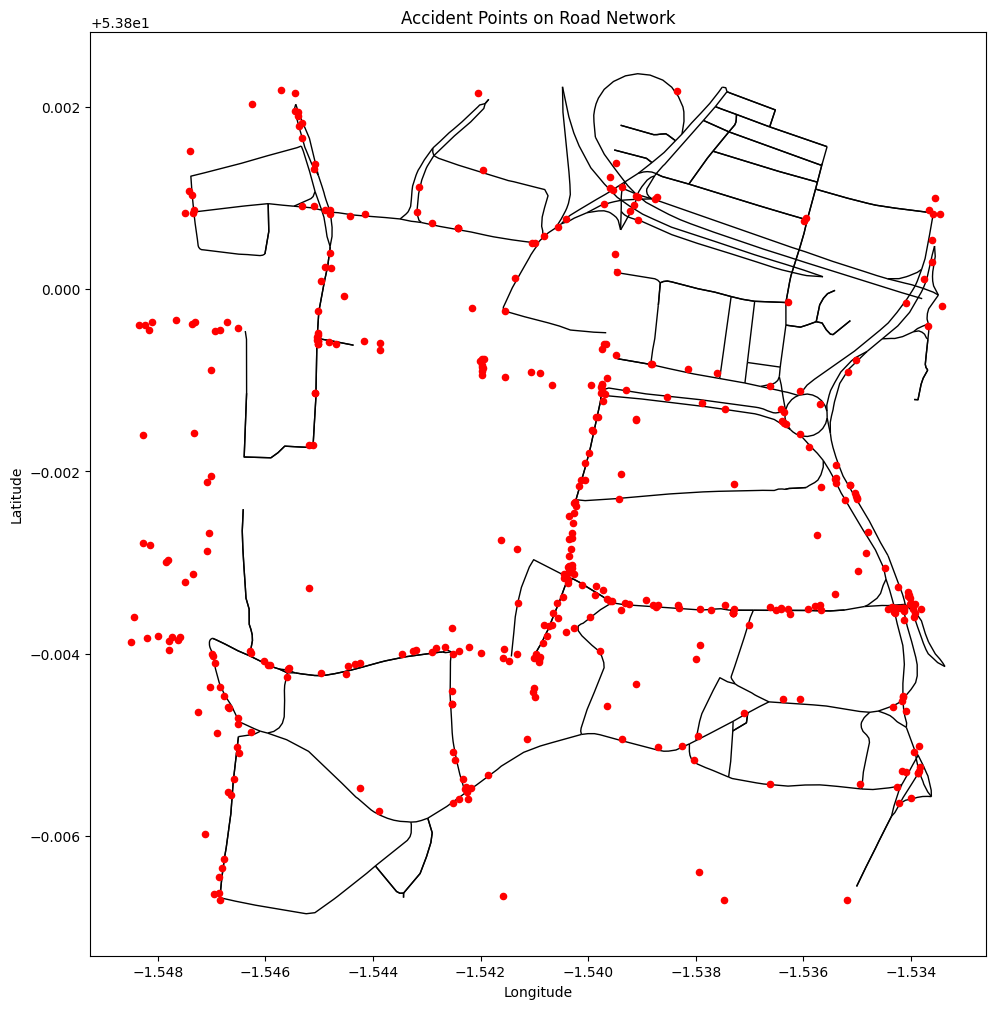

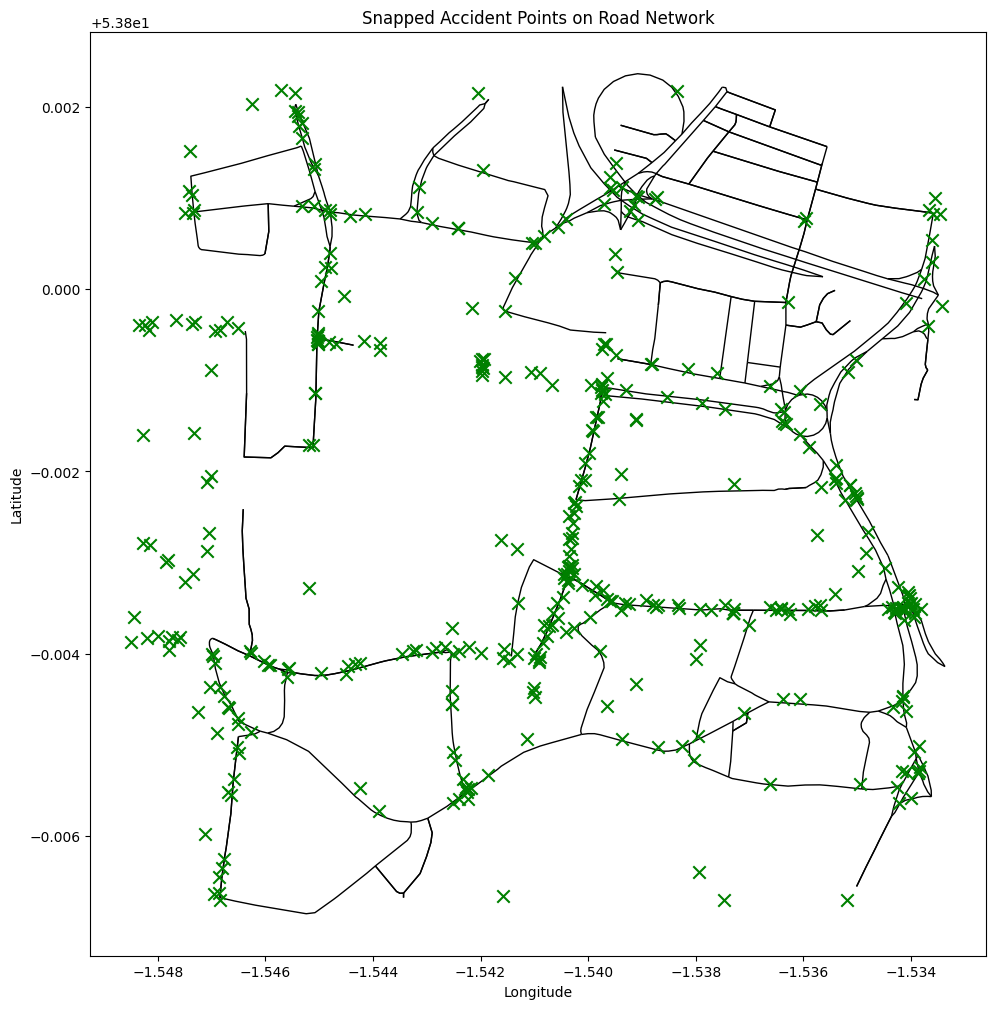

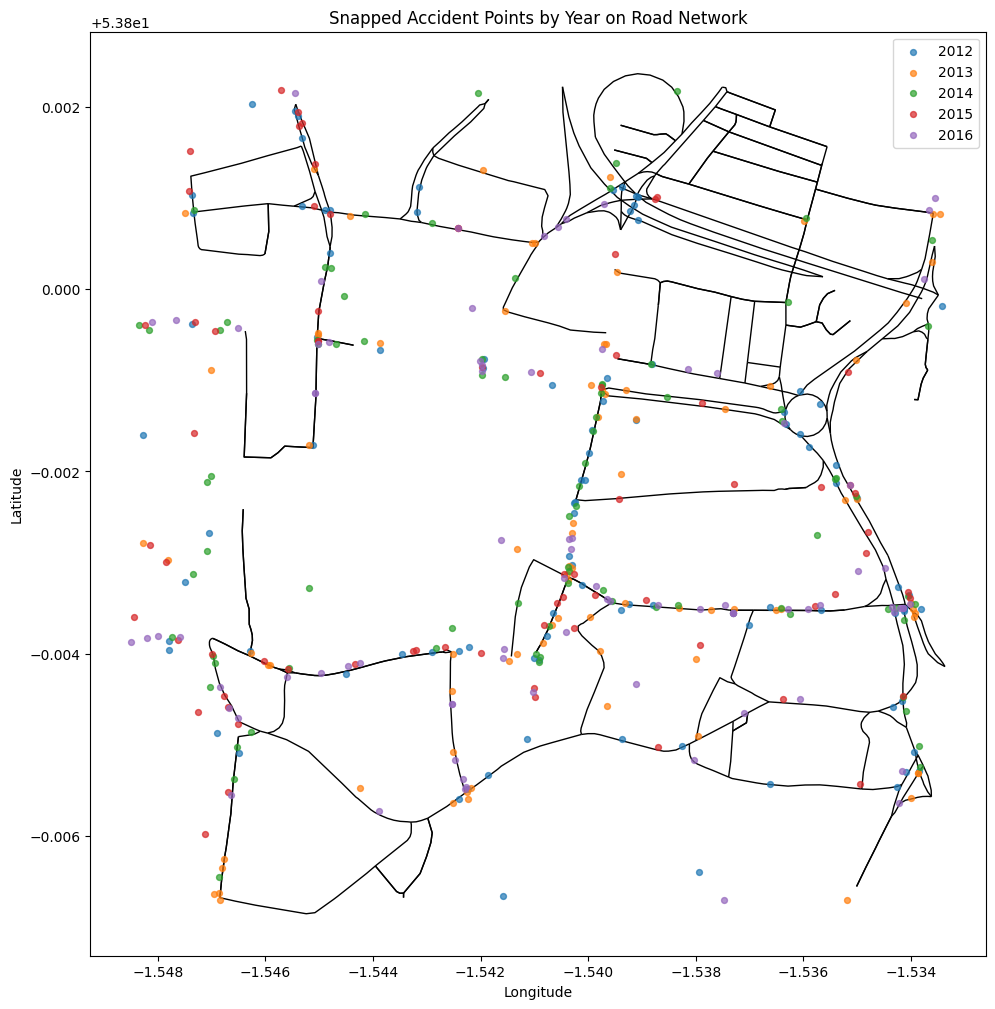

K-function and Moran's I analysis

K-function analysis:
Density of points in the network (lambda): 0.026933231795855626
Number of distance bands: 50



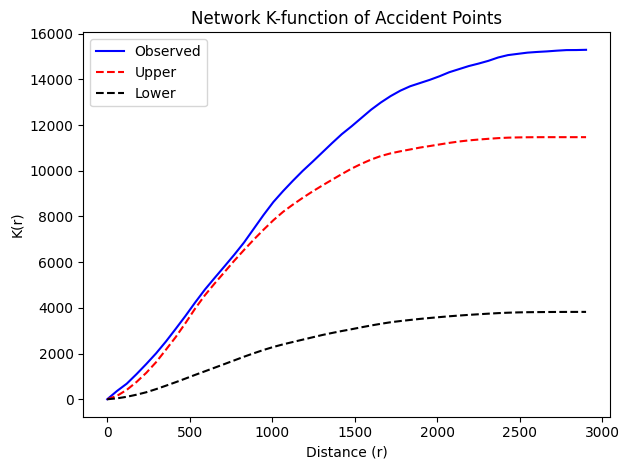

Accident counts for each segment:
Number of road segments where at least one accident has occurred: 253

Moran input:
Number of edges in the weights matrix: 1172
Number of values prepared: 1172

Moran's I analysis:
Moran's I: 0.1825921412632418
P-value from simulation: 0.001



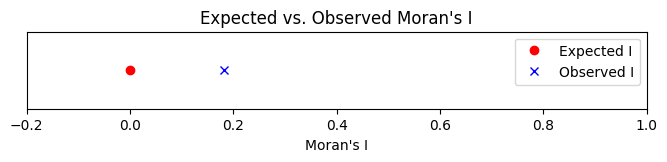

The accident position relative to the intersections

Position of accidents on each segment:
Number of snapped accidents analysed: 413

Summary of accident position:
The mean of fraction: 0.20317627767271168
The median of fraction: 0.17239582036881168
Maximum of fraction: 0.4975490567533891
Minimum of fraction: 0.0
On average, traffic accidents are more common near intersections than in the middle of road segments.



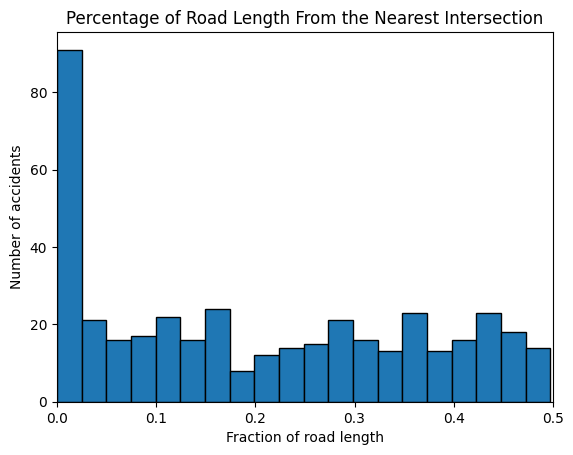

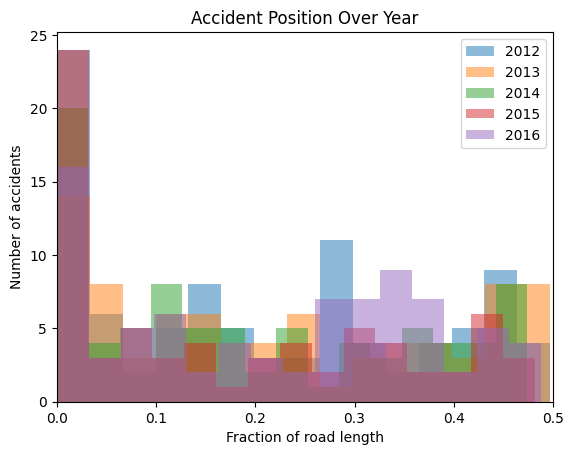

In [9]:
def accident_position(road_network, accidents_for_snap):
    point_pattern=road_network.pointpatterns['accidents']
    point_arc={}
    for arc in point_pattern.obs_to_arc:
        point_info=point_pattern.obs_to_arc[arc]
        for point_id in point_info:
            point_arc[point_id]=arc
    
    position=[]
    point_ids=[]
    for point_id in point_pattern.points:
        arc=point_arc[point_id]
        arc_length=road_network.arc_lengths[arc]
        distance_dict=point_pattern.dist_to_vertex[point_id]
        distance_list=list(distance_dict.values())

        nearest_inter_distance=min(distance_list)
        fraction_to_nearest_inter=nearest_inter_distance/arc_length
        snapped_x, snapped_y=point_pattern.snapped_coordinates[point_id]
        position.append({
            'point_id':point_id,
            'arc':arc,
            'arc_length':arc_length,
            'distance_to_nearest_intersection':nearest_inter_distance,
            'fraction_to_nearest_intersection':fraction_to_nearest_inter,
            'geometry':Point(snapped_x, snapped_y)
        })
        point_ids.append(point_id)

    accident_position_gdf=gpd.GeoDataFrame(position, geometry='geometry', crs=accidents_for_snap.crs)
    accidents_for_snap=accidents_for_snap.copy()
    accidents_for_snap['point_id']=accidents_for_snap.index

    accident_position_gdf=accident_position_gdf.merge(accidents_for_snap[['point_id', 'reference_number', 'year', 'accident_date']], on='point_id', how='left')
    print('Position of accidents on each segment:')
    print('Number of snapped accidents analysed:', len(accident_position_gdf))
    print()
    return accident_position_gdf

def summary_accident_position(accident_position_gdf):
    fraction_mean=accident_position_gdf['fraction_to_nearest_intersection'].mean()
    fraction_median=accident_position_gdf['fraction_to_nearest_intersection'].median()
    fraction_max=accident_position_gdf['fraction_to_nearest_intersection'].max()
    fraction_min=accident_position_gdf['fraction_to_nearest_intersection'].min()

    print('Summary of accident position:')
    print('The mean of fraction:', fraction_mean)
    print('The median of fraction:', fraction_median)
    print('Maximum of fraction:', fraction_max)
    print('Minimum of fraction:', fraction_min)

    if fraction_mean<0.25:
        print('On average, traffic accidents are more common near intersections than in the middle of road segments.')
    elif fraction_mean>0.25:
        print('On average, traffic accidents are more common in the middle of a road segment than near intersections.')
    else:
        print('Overall, the distribution of road traffic accidents at intersections and on road segments is broadly similar.')
    print()

    result={
        'fraction_mean':fraction_mean,
        'fraction_median':fraction_median,
        'fraction_max':fraction_max,
        'fraction_min':fraction_min
    }
    return result

def plot_histogram_accident_position(accident_position_gdf):
    plt.figure()
    plt.hist(accident_position_gdf['fraction_to_nearest_intersection'], bins=20, edgecolor='black')
    plt.title('Percentage of Road Length From the Nearest Intersection')
    plt.xlabel('Fraction of road length')
    plt.ylabel('Number of accidents')
    plt.xlim(0, 0.5)
    plt.show()

def plot_accident_position_by_year(accident_position_gdf):
    plt.figure()
    year_list=sorted(accident_position_gdf['year'].dropna().unique())

    for year in year_list:
        year_data=accident_position_gdf[accident_position_gdf['year']==year]
        plt.hist(year_data['fraction_to_nearest_intersection'], bins=15, alpha=0.5, label=str(year))
    plt.title('Accident Position Over Year')
    plt.xlabel('Fraction of road length')
    plt.ylabel('Number of accidents')
    plt.xlim(0, 0.5)
    plt.legend()
    plt.show()

def run_task_b(accident_points, best_area, graph_road_projected):
    accidents_area=select_accidents_best_area(accident_points, best_area)
    road_network, nodes_df, edges_df=spaghetti_network(graph_road_projected)
    accidents_snap=snap_accidents_to_network(road_network, edges_df, accidents_area)
    snapped_accidents_gdf=snapped_accident(road_network, accidents_snap)

    print('Plot road accidents on the road network')
    print()
    plot_accidents_on_network(edges_df, accidents_area)
    plot_snapped_accidents_on_network(edges_df, snapped_accidents_gdf)
    plot_snapped_accidents_by_year(edges_df, snapped_accidents_gdf)

    print("K-function and Moran\'s I analysis")
    print()
    kres=calculate_k_function(road_network, nsteps=50, permutations=100)
    plot_k_function(kres)
    counts=count_accidents_each_road(road_network)
    moran, weights, edges, values, expected_I=calculate_moran_i(road_network, counts)
    plot_moran(moran, expected_I)

    print('The accident position relative to the intersections')
    print()
    accident_position_gdf=accident_position(road_network, accidents_snap)
    position_summary=summary_accident_position(accident_position_gdf)
    plot_histogram_accident_position(accident_position_gdf)
    plot_accident_position_by_year(accident_position_gdf)

    result={
        'accidents_area':accidents_area,
        'road_network':road_network,
        'nodes_df':nodes_df,
        'edges_df':edges_df,
        'accidents_snap':accidents_snap,
        'snapped_accidents_gdf':snapped_accidents_gdf,
        'kres':kres,
        'counts':counts,
        'moran':moran,
        'weights':weights,
        'edges':edges,
        'values':values,
        'expected_I':expected_I,
        'accident_position_gdf':accident_position_gdf,
        'position_summary':position_summary
    }
    return result

task_b_outcome=run_task_b(accident_points, best_area, graph_road_projected)

## Task C

The following functions are used to select the initial marathon seed points. First, accident points from Task B are linked to neighbouring nodes in the road network, and a local accident count is assigned to each node. Nodes with relatively low local accident counts are considered safer candidate points; the final seed points are then selected to ensure that they are both relatively safe and evenly distributed across the network.

In [10]:
def nearest_accident_node(component, snapped_accidents_gdf):
    snapped_accidents_projected=snapped_accidents_gdf.to_crs(component.graph['crs']).copy()
    nodes_nearest=[]
    for geometry in snapped_accidents_projected.geometry:
        node_nearest=ox.distance.nearest_nodes(component, X=geometry.x, Y=geometry.y)
        nodes_nearest.append(node_nearest)
    
    nearest_accident=pd.DataFrame({'node_nearest':nodes_nearest})
    accident_count_node=nearest_accident['node_nearest'].value_counts().to_dict()
    print('Nearest accident nodes:')
    print('Accident points allocated to the nearest nodes:', len(nodes_nearest))
    print('The number of nodes where at least one accident has occurred nearby:', len(accident_count_node))
    print()
    return accident_count_node

def safety_node(component, accident_count_node):
    node_records=[]
    for node in component.nodes():
        x=component.nodes[node]['x']
        y=component.nodes[node]['y']

        if node in accident_count_node:
            accident_count=accident_count_node[node]
        else:
            accident_count=0
        node_records.append({'node':node, 'x':x, 'y':y, 'accident_count':accident_count})
    node_df=pd.DataFrame(node_records)
    node_df=node_df.sort_values(by=['accident_count'], ascending=True).reset_index(drop=True)

    print('Safety Node:')
    print('Number of candidate nodes:', len(node_df))
    print()
    return node_df
    
def select_safe_nodes(node_df):
    median_accident_count=node_df['accident_count'].median()
    safe_candidates=node_df[node_df['accident_count']<=median_accident_count].copy()
    safe_candidates=safe_candidates.reset_index(drop=True)

    print('Safe candidate nodes:')
    print('Median accident count:', median_accident_count)
    print('Number of safe candidate nodes:', len(safe_candidates))
    print()
    return safe_candidates

def select_seed_points(safe_candidates, number_of_seeds=4):
    #This function selects the final seed node from a set of safer candidate nodes. Starting from an initial node, it repeatedly selects the next node that is as far as possible from the previously selected seed node.
    selected_indices=[0]

    while len(selected_indices)<number_of_seeds:
        best_index=None
        best_distance=-1
        for i in range(len(safe_candidates)):
            if i in selected_indices:
                continue
            candidate_x=safe_candidates.iloc[i]['x']
            candidate_y=safe_candidates.iloc[i]['y']
            min_distance=None

            for selected_index in selected_indices:
                selected_x=safe_candidates.iloc[selected_index]['x']
                selected_y=safe_candidates.iloc[selected_index]['y']
                distance=((candidate_x-selected_x)**2+(candidate_y-selected_y)**2)**0.5
                if min_distance is None or distance<min_distance:
                    min_distance=distance
            if min_distance>best_distance:
                best_distance=min_distance
                best_index=i
        selected_indices.append(best_index)
    selected_seeds=safe_candidates.iloc[selected_indices]['node'].tolist()
    print('Selected seed points:')
    for i in range(len(selected_seeds)):
        print('Seed', i+1, ':', selected_seeds[i])
    print()
    return selected_seeds

def seed_points_gdf(component, selected_seeds):
    seed_records=[]
    for seed in selected_seeds:
        x=component.nodes[seed]['x']
        y=component.nodes[seed]['y']

        seed_records.append({'seed_node':seed, 'geometry':Point(x, y)})
    
    seed_points_gdf=gpd.GeoDataFrame(seed_records, geometry='geometry', crs=component.graph['crs'])
    print('Seed points for a GeoDataFrame:')
    print('Number of selected seed points:', len(seed_points_gdf))
    print()
    return seed_points_gdf

def plot_seed_points(component, selected_seeds):
    all_nodes=list(component.nodes)
    node_colours=['r' if node in selected_seeds else 'w' for node in all_nodes]

    fig, ax=ox.plot_graph(
        component,
        node_color=node_colours,
        edge_color='gray',
        bgcolor='k',
        node_size=18,
        show=False,
        close=False
    )

    for i in range(len(selected_seeds)):
        seed=selected_seeds[i]
        x=component.nodes[seed]['x']
        y=component.nodes[seed]['y']
        label_text='Seed '+str(i+1)
        ax.text(x, y, label_text, color='white', fontsize=10)
    
    plt.title('Initial 4 Seed Points')
    plt.show()



Next, constructed and visualised the Voronoi graph of the network. Each node and edge in the road network was assigned to the nearest seed point in terms of network distance, thereby generating a set of marathon cells. The resulting Voronoi graph illustrated how the selected seed points partition the network into distinct regions for route planning.

In [11]:
def seed(component, selected_seeds):
    cells=nx.voronoi_cells(component, selected_seeds, weight='length')
    cells_inverse={v:key for key, value in cells.items() for v in value}

    print('Voronoi Cells:')
    print('Number of cells:', len(cells))
    print('Number of assigned nodes:', len(cells_inverse))
    print()
    return cells, cells_inverse

def get_seed_color(selected_seeds):
    seed_colors=dict(zip(selected_seeds, ox.plot.get_colors(len(selected_seeds))))
    return seed_colors

def map_node_color(component, cells_inverse, seed_colors):
    node_color_dict={node:seed_colors[cells_inverse[node]] for node in component.nodes}
    return node_color_dict

def map_edge_color(component, cells_inverse, node_color_dict, seed_colors):
    edge_colors=[]
    for edge in component.edges:
        color_pair=[node_color_dict[edge[0]], node_color_dict[edge[1]]]
        if color_pair[0]==color_pair[1]:
            edge_colors.append(color_pair[0])
        else:
            seed_to_u_distance=nx.shortest_path_length(component, cells_inverse[edge[0]], edge[0], weight='length')
            seed_to_v_distance=nx.shortest_path_length(component, cells_inverse[edge[1]], edge[1], weight='length')
            if seed_to_u_distance<=seed_to_v_distance:
                edge_colors.append(color_pair[0])
            else:
                edge_colors.append(color_pair[1])
    return edge_colors

def plot_network_voronoi(component, selected_seeds, edge_colors):
    all_nodes=list(component.nodes)
    node_colors=['r' if node in selected_seeds else 'w' for node in all_nodes]
    fig, ax=ox.plot_graph(component, edge_color=edge_colors, node_color=node_colors, bgcolor='k', node_size=18, edge_linewidth=1.8, show=False, close=False)

    for i in range(len(selected_seeds)):
        seed=selected_seeds[i]
        x=component.nodes[seed]['x']
        y=component.nodes[seed]['y']
        label_text='Seed '+str(i+1)
        ax.text(x, y, label_text, color='white', fontsize=10)
    
    plt.title('Network Voronoi Diagram')
    plt.show()


Search for closed marathon routes within individual Voronoi cells. First, extract the relevant subgraphs of the cells to identify potential start and finish nodes, then construct a closed route by combining an outbound path with a return path. The optimal route is selected based on how closely its total length approximates the target distance of a 42-kilometre marathon.

In [12]:
def get_cell_subgraph(component, cells, selected_seed):
    cell_nodes=list(cells[selected_seed])
    cell_subgraph=component.subgraph(cell_nodes).copy()

    if not nx.is_connected(cell_subgraph):
        largest_nodes=max(nx.connected_components(cell_subgraph), key=len)
        cell_subgraph=cell_subgraph.subgraph(largest_nodes).copy()
    
    print('Cell Subgraph:')
    print('Seed:', selected_seed)
    print('Number of Nodes:', cell_subgraph.number_of_nodes())
    print('Number of Edges:', cell_subgraph.number_of_edges())
    print()
    return cell_subgraph

def edge_length(graph, u, v):#Returns the length of the edge between two nodes. If the graph is a multigraph, the shortest available edge between the two nodes is selected.
    edge_data=graph.get_edge_data(u,v)
    if graph.is_multigraph():
        lengths=[]
        for key in edge_data:
            if 'length' in edge_data[key]:
                lengths.append(edge_data[key]['length'])
            else:
                lengths.append(1)
        return min(lengths)
    else:
        if 'length' in edge_data:
            return edge_data['length']
        else:
            return 1
        
def path_length(graph, path):
    full_length=0

    for i in range(len(path)-1):
        u=path[i]
        v=path[i+1]
        full_length=full_length+edge_length(graph, u, v)
    
    return full_length

def path_edges_remove(graph, path):#Remove the edges used in the forward path from the copy of the graph. For a multigraph, it removes the shortest matching edges.
    graph_copy=graph.copy()
    for i in range(len(path)-1):
        u=path[i]
        v=path[i+1]
        
        if graph_copy.has_edge(u, v):
            if graph_copy.is_multigraph():
                edge_data=graph_copy.get_edge_data(u, v)
                shortest_key=min(edge_data, key=lambda key: edge_data[key].get('length', 1))
                graph_copy.remove_edge(u, v, key=shortest_key)
            else:
                graph_copy.remove_edge(u, v)
    return graph_copy

def close_route(graph, start_node, target_node):#Construct a closed route between the start node and the end node. It first finds the shortest path from the start to the end, removes those edges, and then finds a path back to the start.
    try:
        forward_path=nx.shortest_path(graph, start_node, target_node, weight='length')
        forward_length=path_length(graph, forward_path)
        graph_without_forward=path_edges_remove(graph, forward_path)
        return_path=nx.shortest_path(graph_without_forward, target_node, start_node, weight='length')
        return_length=path_length(graph_without_forward, return_path)

        closed_route=forward_path+return_path[1:]
        full_length=forward_length+return_length

        outcome={
            'start_node':start_node,
            'target_node':target_node,
            'forward_path':forward_path,
            'return_path':return_path,
            'route':closed_route,
            'route_length':full_length,
            'gap_to_target':abs(full_length-42000)
        }
        return outcome
    
    except:
        return None
    

def candidate_start_nodes(cell_subgraph, number_of_starts=5):
    degree_list=[]
    for node in cell_subgraph.nodes():
        degree_list.append((node, cell_subgraph.degree(node)))
    
    degree_list=sorted(degree_list, key=lambda row: row[1], reverse=True)
    start_nodes=[]
    for row in degree_list:
        if row[1]>=2:
            start_nodes.append(row[0])
    
    start_nodes=start_nodes[:number_of_starts]
    print('Candidate start nodes:')
    print('Number of candidiate starts:', len(start_nodes))
    print()
    return start_nodes

def candidate_target_nodes(cell_subgraph, start_node):
    distances=nx.single_source_dijkstra_path_length(cell_subgraph, start_node, weight='length')
    target_rows=[]
    for node in distances:
        if node!=start_node:
            target_rows.append((node, distances[node]))
    target_rows=sorted(target_rows, key=lambda row: row[1], reverse=True)
    target_nodes=[row[0] for row in target_rows]
    return target_nodes

def find_best_closed_route(cell_subgraph, target_length=42000, number_of_starts=5):
    #By testing multiple starting points and multiple destination points, it searches for the optimal closed route within the grid. 
    # For each candidate route, it calculates the difference between the total route length and the target distance of 42 kilometres (a marathon), and retains the best result.
    start_nodes=candidate_start_nodes(cell_subgraph, number_of_starts=number_of_starts)
    best_outcome=None
    best_gap=None

    for start_node in start_nodes:
        target_nodes=candidate_target_nodes(cell_subgraph, start_node)
        for target_node in target_nodes:
            route_outcome=close_route(cell_subgraph, start_node, target_node)

            if route_outcome is None:
                continue
            best_gap_current=abs(route_outcome['route_length']-target_length)
            if best_gap is None or best_gap_current<best_gap:
                best_gap=best_gap_current
                best_outcome=route_outcome
    print('Best closed route')
    print('Route length(m):', best_outcome['route_length'])
    print('Gap to target:', best_outcome['gap_to_target'])
    print()
    return best_outcome

def plot_cell_route(cell_subgraph, route_outcome, selected_seed):
    route=route_outcome['route']
    fig, ax=ox.plot_graph_route(cell_subgraph, route, bgcolor='k', node_color='w', edge_color='gray', route_color='red', route_linewidth=3, node_size=18, show=False, close=False)

    start_node=route_outcome['start_node']
    x=cell_subgraph.nodes[start_node]['x']
    y=cell_subgraph.nodes[start_node]['y']
    ax.text(x, y, 'Start / Finish', color='yellow', fontsize=10)
    plt.title('Closed Route in Cell of Seed ' + str(selected_seed))
    plt.show()

def run_marathon_route(component, cells, selected_seed, target_length=42000, number_of_starts=5):
    cell_subgraph=get_cell_subgraph(component, cells, selected_seed)
    route_outcome=find_best_closed_route(cell_subgraph, target_length=target_length, number_of_starts=number_of_starts)
    plot_cell_route(cell_subgraph, route_outcome, selected_seed)
    outcome={'cell_subgraph':cell_subgraph, 'route_outcome':route_outcome}
    return outcome

Nearest accident nodes:
Accident points allocated to the nearest nodes: 413
The number of nodes where at least one accident has occurred nearby: 96

Safety Node:
Number of candidate nodes: 169

Safe candidate nodes:
Median accident count: 1.0
Number of safe candidate nodes: 103

Selected seed points:
Seed 1 : 342579576
Seed 2 : 8326384273
Seed 3 : 247352905
Seed 4 : 342626322

Voronoi Cells:
Number of cells: 4
Number of assigned nodes: 169

Cell 1
Selected seed: 342579576

Cell Subgraph:
Seed: 342579576
Number of Nodes: 77
Number of Edges: 102

Candidate start nodes:
Number of candidiate starts: 5

Best closed route
Route length(m): 1912.9923156804873
Gap to target: 40087.00768431951



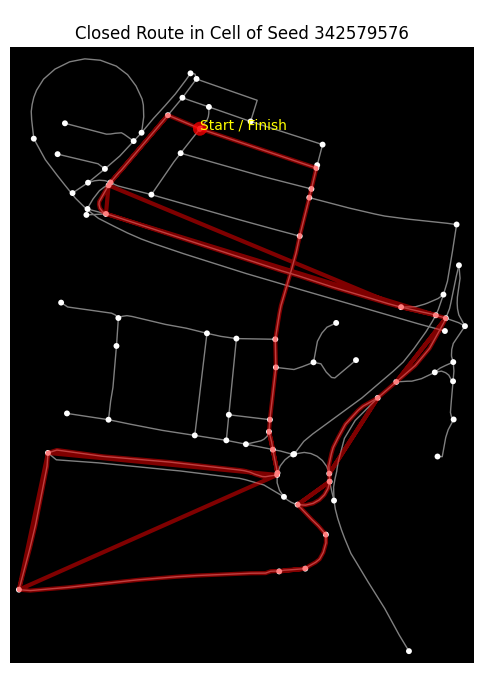

Cell 2
Selected seed: 8326384273

Cell Subgraph:
Seed: 8326384273
Number of Nodes: 24
Number of Edges: 29

Candidate start nodes:
Number of candidiate starts: 5

Best closed route
Route length(m): 1119.9450045353522
Gap to target: 40880.05499546465



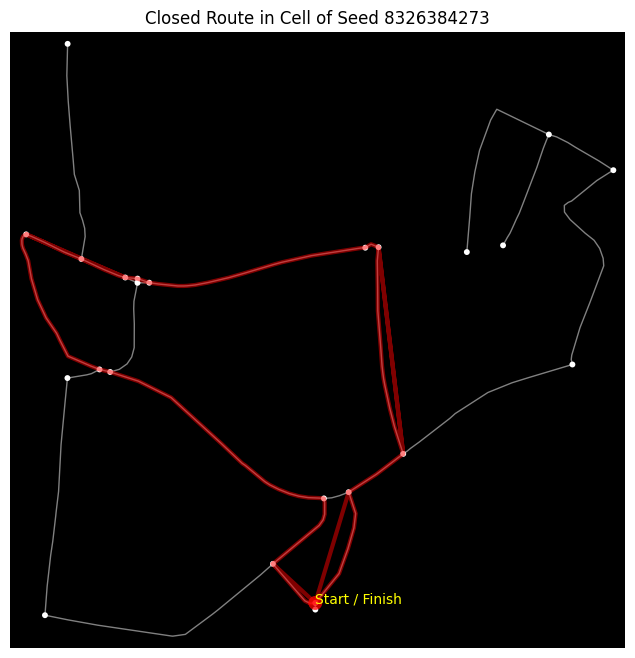

Cell 3
Selected seed: 247352905

Cell Subgraph:
Seed: 247352905
Number of Nodes: 35
Number of Edges: 46

Candidate start nodes:
Number of candidiate starts: 5

Best closed route
Route length(m): 989.2422854386049
Gap to target: 41010.7577145614



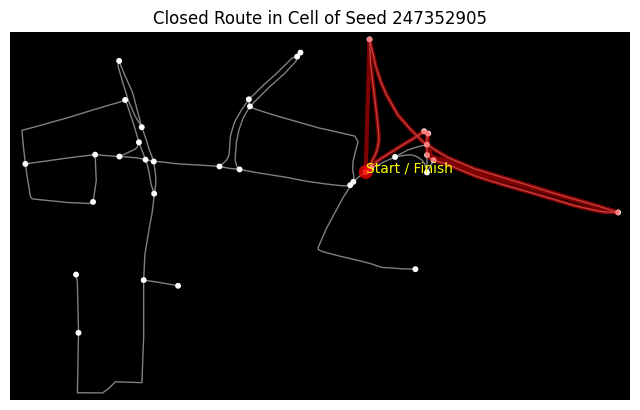

Cell 4
Selected seed: 342626322

Cell Subgraph:
Seed: 342626322
Number of Nodes: 33
Number of Edges: 47

Candidate start nodes:
Number of candidiate starts: 5

Best closed route
Route length(m): 862.177459679423
Gap to target: 41137.82254032058



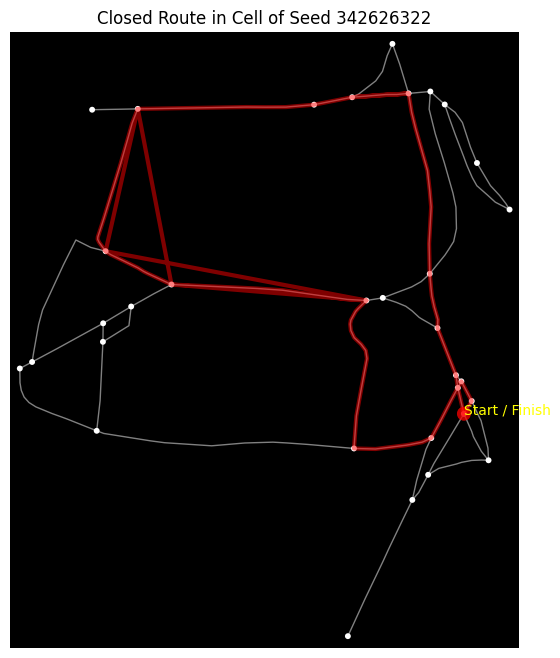

Route Summary Table:
   cell_number  selected_seed  number_of_nodes  number_of_edges  route_length  \
0            1      342579576               77              102   1912.992316   
1            2     8326384273               24               29   1119.945005   
2            3      247352905               35               46    989.242285   
3            4      342626322               33               47    862.177460   

   gap_to_target  
0   40087.007684  
1   40880.054995  
2   41010.757715  
3   41137.822540  



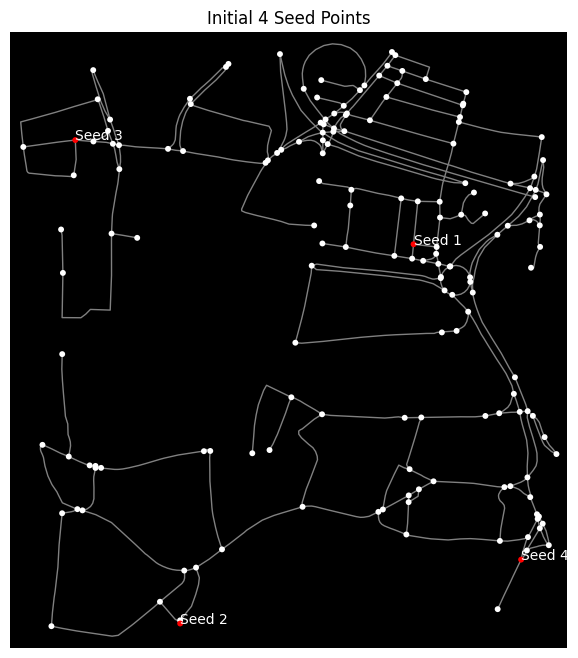

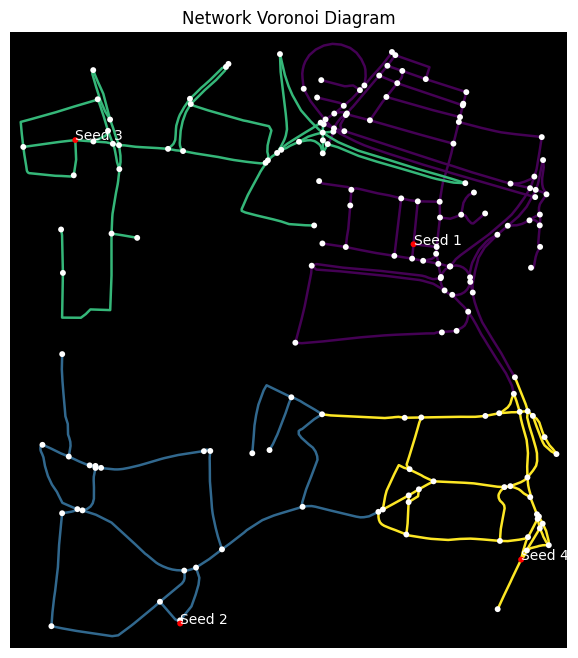

In [13]:
def run_all_cells_routes(component, cells, selected_seeds, target_length=42000, number_of_starts=5):
    all_outcome=[]

    for i in range(len(selected_seeds)):
        selected_seed=selected_seeds[i]
        print('Cell', i+1)
        print('Selected seed:', selected_seed)
        print()

        route_result=run_marathon_route(component, cells, selected_seed, target_length=target_length, number_of_starts=number_of_starts)

        summary_row={
            'cell_number':i+1,
            'selected_seed':selected_seed,
            'number_of_nodes':route_result['cell_subgraph'].number_of_nodes(),
            'number_of_edges':route_result['cell_subgraph'].number_of_edges(),
            'route_length':route_result['route_outcome']['route_length'],
            'gap_to_target':route_result['route_outcome']['gap_to_target']
        }
        all_outcome.append({
            'cell_number':i+1,
            'selected_seed':selected_seed,
            'cell_subgraph':route_result['cell_subgraph'],
            'route_outcome':route_result['route_outcome'],
            'summary_row':summary_row
        })
    return all_outcome
    
def route_summary_table_2(all_outcome):
    summary_records=[]
    for outcome in all_outcome:
        summary_records.append(outcome['summary_row'])
    summary_df_2=pd.DataFrame(summary_records)
    print('Route Summary Table:')
    print(summary_df_2)
    print()
    return summary_df_2
accident_count_node=nearest_accident_node(component, task_b_outcome['snapped_accidents_gdf'])
node_df=safety_node(component, accident_count_node)
safe_candidates=select_safe_nodes(node_df)
selected_seeds=select_seed_points(safe_candidates, number_of_seeds=4)
cells, cells_inverse=seed(component, selected_seeds)
all_cell_results=run_all_cells_routes(component, cells, selected_seeds, target_length=42000, number_of_starts=5)
route_summary_df=route_summary_table_2(all_cell_results)
plot_seed_points(component, selected_seeds)
seed_colors=get_seed_color(selected_seeds)
node_color_dict=map_node_color(component, cells_inverse, seed_colors)
edge_colors=map_edge_color(component, cells_inverse, node_color_dict, seed_colors)
plot_network_voronoi(component, selected_seeds, edge_colors)

By expanding the scope of the study area and rerunning the route analysis using different initial settings

`get_larger_best_area(centre_point, window_size=4500)` created a larger study area centred on the same Leeds reference point. It no longer used the original 1 km2 area, but instead defined a larger square bounding box for the analysis of the revised Task C.

Following this, `build_larger_component(larger_best_area)` constructed a road network component covering a larger study area. It did this by downloading road network data, applying a projection, converting it into an undirected graph, and extracting the largest connected component.

The Point of Leeds Civic Hall Centre:
Easting: 429831.38488280564
Northing: 434088.41618407954
Selected Bounding Box:
west: 427581.38488280564
south: 431838.41618407954
east: 432081.38488280564
north: 436338.41618407954

Convert bounding box to OSMnx:
west -1.58290653371644
south 53.7819063162233
east -1.514150187666871
north 53.822607781240784

Road network loaded.
Number of nodes: 3829
Number of edges: 8509

Projected road network.
CRS: EPSG:32630

Undirect road network:
Number of nodes: 3829
Number of edges: 4908

The largest connected components:
Number of nodes: 3829
Number of edges: 4908

Nearest accident nodes:
Accident points allocated to the nearest nodes: 413
The number of nodes where at least one accident has occurred nearby: 104

Safety Node:
Number of candidate nodes: 3829

Safe candidate nodes:
Median accident count: 0.0
Number of safe candidate nodes: 3725

Selected seed points:
Seed 1 : 350966
Seed 2 : 248497602

Voronoi Cells:
Number of cells: 2
Number of assigned node

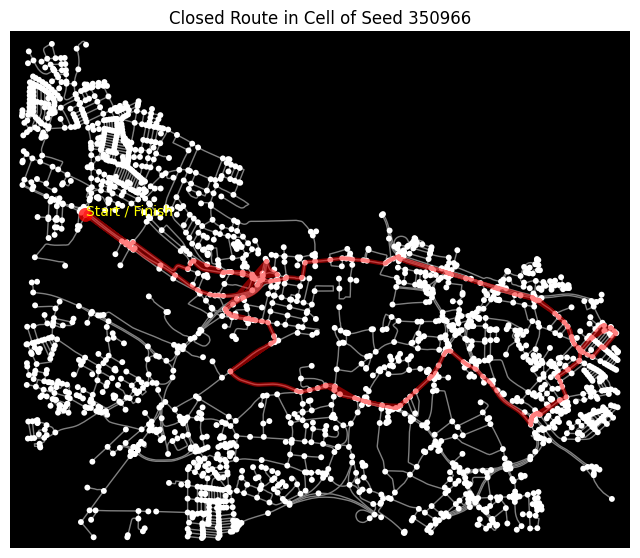

Cell Subgraph:
Seed: 248497602
Number of Nodes: 1687
Number of Edges: 2145

Candidate start nodes:
Number of candidiate starts: 5

Best closed route
Route length(m): 9395.21986634175
Gap to target: 32604.78013365825



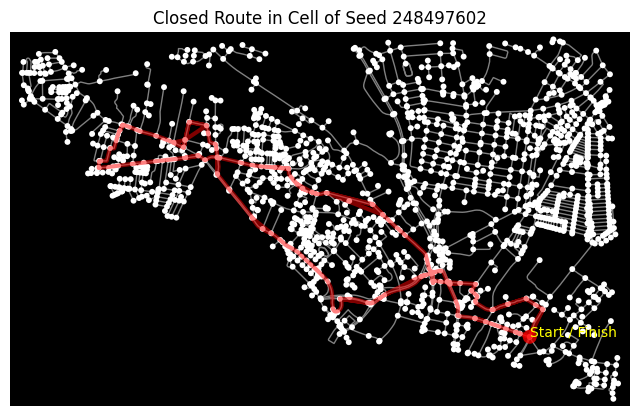

Route Summary Table
   cell_number  selected_seed  number_of_nodes  number_of_edges  route_length  \
0            1         350966             2142             2717  12194.650566   
1            2      248497602             1687             2145   9395.219866   

   gap_to_target  
0   29805.349434  
1   32604.780134  


In [14]:
def get_larger_best_area(centre_point, window_size=4500):
    half_size=window_size/2
    centre_x=centre_point.x
    centre_y=centre_point.y
    larger_box=box(
        centre_x-half_size,
        centre_y-half_size,
        centre_x+half_size,
        centre_y+half_size
    )
    larger_best_area_gdf=gpd.GeoDataFrame({'geometry':[larger_box]}, crs='EPSG:27700')

    larger_best_area=larger_best_area_gdf.iloc[0]
    return larger_best_area

def build_larger_component(larger_best_area):
    graph_larger=build_road_network(larger_best_area)
    graph_larger_projected=projected_road_network(graph_larger)
    graph_larger_undirected=build_undirect_graph(graph_larger_projected)
    larger_component=build_largest_component(graph_larger_undirected)
    return graph_larger, graph_larger_projected, graph_larger_undirected, larger_component

def route_summary_table(all_outcome):
    summary_records=[]
    for outcome in all_outcome:
        summary_records.append(outcome['summary_row'])
    summary_df=pd.DataFrame(summary_records)
    return summary_df

def run_all_cells_routes_2(component, cells, selected_seeds, target_length=42000, number_of_starts=5):
    summary_records=[]
    for i in range(len(selected_seeds)):
        selected_seed=selected_seeds[i]

        route_results=run_marathon_route(component, cells, selected_seed, target_length=target_length, number_of_starts=number_of_starts)
        summary_records.append({
            'cell_number':i+1,
            'selected_seed':selected_seed,
            'number_of_nodes':route_results['cell_subgraph'].number_of_nodes(),
            'number_of_edges':route_results['cell_subgraph'].number_of_edges(),
            'route_length':route_results['route_outcome']['route_length'],
            'gap_to_target':route_results['route_outcome']['gap_to_target']
        })
    
    return pd.DataFrame(summary_records)

centre_point=get_leeds_centre_point()
larger_best_area=get_larger_best_area(centre_point, window_size=4500)
graph_larger, graph_larger_projected, graph_larger_undirected, larger_component=build_larger_component(larger_best_area)
accident_count_node_larger=nearest_accident_node(larger_component, task_b_outcome['snapped_accidents_gdf'])
node_df_larger=safety_node(larger_component, accident_count_node_larger)
safe_candidates_larger=select_safe_nodes(node_df_larger)
selected_seeds_larger_2=select_seed_points(safe_candidates_larger, number_of_seeds=2)
cells_larger_2, cells_inverse_larger_2=seed(larger_component, selected_seeds_larger_2)

route_summary_df_larger_2=run_all_cells_routes_2(larger_component, cells_larger_2, selected_seeds_larger_2, target_length=42000, number_of_starts=5)
print('Route Summary Table')
print(route_summary_df_larger_2)
